## **Term Project #1 (200 points)**
- Instructor: [Jaeung Sim](https://jaeungs.github.io/) (University of Connecticut)
- Course: OPIM 5671 Data Mining and Time Series Forecasting
- Release Date: February 11 (Wed), 2026
- Submission Due:
  - **Mar 1 (Sun), 2026:**
    1. Python notebook (*use this template*)
    2. Excel sheet with predicted values (*a separate template available*)
  - **Mar 4 (Wed), 2026:**
    3. Presentation slides


**Objective**
* In this project, you will forecast weekly end prices of selected stocks listed in NASDAQ, which is closely related to Hands-on Homework #2.
* In doing so, you should submit two types of forecasting results, one of which is fully based on your forecasting model, while the other is the prediction adjusted by human insights and intuition.
* For each company, the best of these two predictions will be considered in evaluation.


**Specify the teammates here:**

- Tracie Le
- Farhan Chowdhury
- Pallav Singh
- Areeb Irfan
- Mohammad Rahim

#### **Technical Details**

# **Model 1 - Time series model**

In [44]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [45]:
# Install & import required libraries

!pip install pmdarima yfinance statsmodels scikit-learn

import yfinance as yf
import pandas as pd
import numpy as np
from pmdarima import auto_arima
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [46]:
import os

# List contents of the expected directory to verify paths and filenames
drive_path = '/content/drive/MyDrive/OPIM 5671_Data Mining/Project Term/'

try:
    print(f"Listing contents of: {drive_path}")
    for item in os.listdir(drive_path):
        print(item)
except FileNotFoundError:
    print(f"Error: Directory not found at {drive_path}. Please verify the path in your Google Drive.")
except Exception as e:
    print(f"An error occurred: {e}")

Listing contents of: /content/drive/MyDrive/OPIM 5671_Data Mining/Project Term/
OPIM_5671_Term_Project_01_Forecasts.xlsx
Old
OPIM_5671_Term_Project_01_Main File.ipynb


In [47]:
import yfinance as yf
import pandas as pd

# Initialize the data dictionary once at the beginning
data = {}

# Add NASDAQ and S&P directly
index_tickers = {
    "NASDAQ": "^IXIC",
    "SP500": "^GSPC"
}

for name, ticker in index_tickers.items():
    print(f"Downloading {name} ({ticker})...")
    df = yf.download(ticker, period="5y")
    data[name] = df['Close'].resample('W-FRI').last()

# Define ticker symbols
tickers = ["ADBE", "AMZN", "AAL", "AAPL", "AZN", "NVDA", "SBUX", "TSLA", "UAL", "WMG", "WEN"]

# Download historical data for individual tickers
# Convert daily data → weekly (Friday closing price)
for ticker in tickers:
    print(f"Downloading {ticker} stock data...")
    df = yf.download(ticker, period="5y") # yfinance.download can directly get data
    data[ticker] = df['Close'].resample('W-FRI').last()


/tmp/ipython-input-233/4017023100.py:15: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, period="5y")
[*********************100%***********************]  1 of 1 completed


/tmp/ipython-input-233/4017023100.py:15: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, period="5y")
[*********************100%***********************]  1 of 1 completed
/tmp/ipython-input-233/4017023100.py:25: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, period="5y") # yfinance.download can directly get data
[*********************100%***********************]  1 of 1 completed
/tmp/ipython-input-233/4017023100.py:25: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, period="5y") # yfinance.download can directly get data


[*********************100%***********************]  1 of 1 completed
/tmp/ipython-input-233/4017023100.py:25: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, period="5y") # yfinance.download can directly get data
[*********************100%***********************]  1 of 1 completed
/tmp/ipython-input-233/4017023100.py:25: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, period="5y") # yfinance.download can directly get data


[*********************100%***********************]  1 of 1 completed
/tmp/ipython-input-233/4017023100.py:25: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, period="5y") # yfinance.download can directly get data
[*********************100%***********************]  1 of 1 completed


/tmp/ipython-input-233/4017023100.py:25: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, period="5y") # yfinance.download can directly get data
[*********************100%***********************]  1 of 1 completed


/tmp/ipython-input-233/4017023100.py:25: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, period="5y") # yfinance.download can directly get data
[*********************100%***********************]  1 of 1 completed
/tmp/ipython-input-233/4017023100.py:25: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, period="5y") # yfinance.download can directly get data
[*********************100%***********************]  1 of 1 completed
/tmp/ipython-input-233/4017023100.py:25: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, period="5y") # yfinance.download can directly get data


[*********************100%***********************]  1 of 1 completed
/tmp/ipython-input-233/4017023100.py:25: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, period="5y") # yfinance.download can directly get data
[*********************100%***********************]  1 of 1 completed
/tmp/ipython-input-233/4017023100.py:25: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, period="5y") # yfinance.download can directly get data


[*********************100%***********************]  1 of 1 completed


In [48]:
results = {}

for ticker in tickers:

    ts = data[ticker].dropna()

    # Align exogenous variables with the target
    exog = pd.concat([data['NASDAQ'], data['SP500']], axis=1)
    exog.columns = ['NASDAQ', 'SP500']

    combined = pd.concat([ts, exog], axis=1).dropna()

    y = combined[ticker]
    X = combined[['NASDAQ', 'SP500']]

    # 80/20 split
    train_size = int(len(y) * 0.8)

    y_train, y_test = y[:train_size], y[train_size:]
    X_train, X_test = X[:train_size], X[train_size:]

    # Auto ARIMA with exogenous variables
    auto_model = auto_arima(
        y_train,
        exogenous=X_train,
        seasonal=False,
        error_action='ignore',
        suppress_warnings=True
    )

    optimal_order = auto_model.order

    # Forecast on test set
    forecast_test = auto_model.predict(
        n_periods=len(y_test),
        exogenous=X_test
    )

    mae = mean_absolute_error(y_test, forecast_test)
    mse = mean_squared_error(y_test, forecast_test)

    # Fit full ARIMAX model
    model_full = ARIMA(
        y,
        order=optimal_order,
        exog=X
    ).fit()

    # For future forecasting → use last known index values
    future_exog = X.iloc[-5:]   # Simple assumption (can improve)

    forecast_5weeks = model_full.forecast(
        steps=5,
        exog=future_exog
    )

    future_index = pd.date_range(
        start=y.index[-1] + pd.Timedelta(weeks=1),
        periods=5,
        freq='W-FRI'
    )

    results[ticker] = {
        'model_order': optimal_order,
        'MAE': mae,
        'MSE': mse,
        'forecast_5weeks': pd.Series(forecast_5weeks, index=future_index)
    }

In [49]:
# Print model summary
for ticker, res in results.items():
    print(f"{ticker}: Order {res['model_order']}, MAE={res['MAE']:.2f}, MSE={res['MSE']:.2f}")
    print("Forecast 5 weeks ahead:", res['forecast_5weeks'])
    print()

ADBE: Order (0, 1, 0), MAE=90.69, MSE=9867.60
Forecast 5 weeks ahead: 2026-03-06    284.177740
2026-03-13    272.868173
2026-03-20    258.427812
2026-03-27    268.658917
2026-04-03    262.410004
Freq: W-FRI, Name: predicted_mean, dtype: float64

AMZN: Order (0, 1, 0), MAE=14.69, MSE=316.94
Forecast 5 weeks ahead: 2026-03-06    223.668837
2026-03-13    215.507844
2026-03-20    208.869051
2026-03-27    213.346716
2026-04-03    210.000000
Freq: W-FRI, Name: predicted_mean, dtype: float64

AAL: Order (0, 1, 0), MAE=2.74, MSE=10.06
Forecast 5 weeks ahead: 2026-03-06    13.431943
2026-03-13    13.305309
2026-03-20    12.924375
2026-03-27    13.207371
2026-04-03    13.070000
Freq: W-FRI, Name: predicted_mean, dtype: float64

AAPL: Order (0, 1, 0), MAE=26.88, MSE=1102.78
Forecast 5 weeks ahead: 2026-03-06    270.152991
2026-03-13    267.445212
2026-03-20    262.575869
2026-03-27    266.110213
2026-04-03    264.179993
Freq: W-FRI, Name: predicted_mean, dtype: float64

AZN: Order (0, 1, 1), MAE=

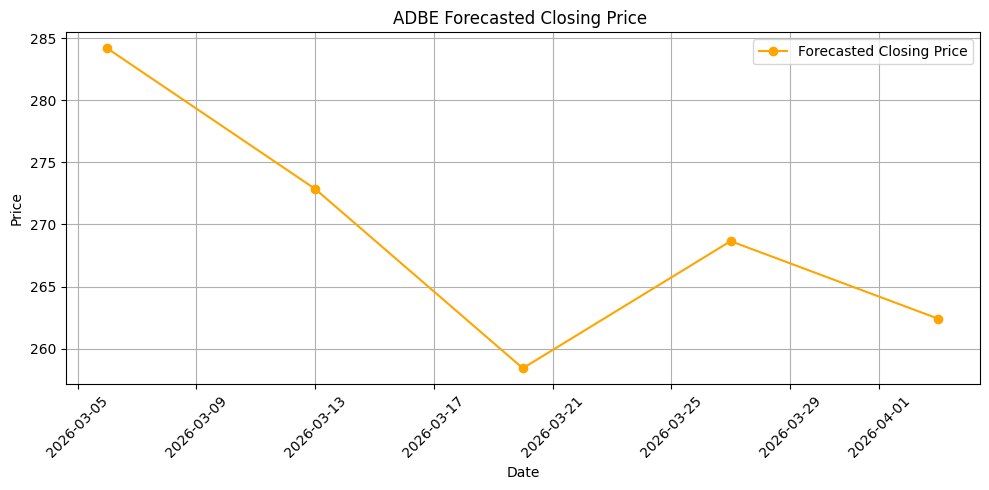

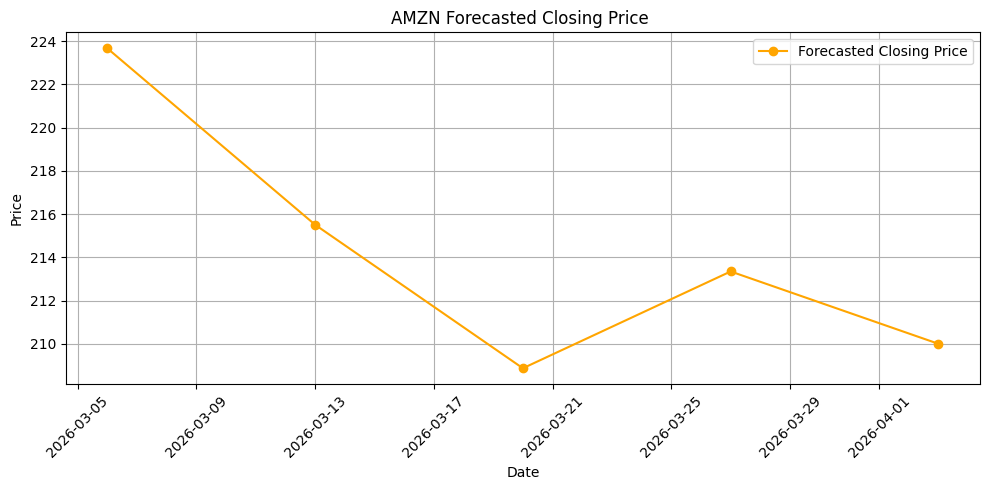

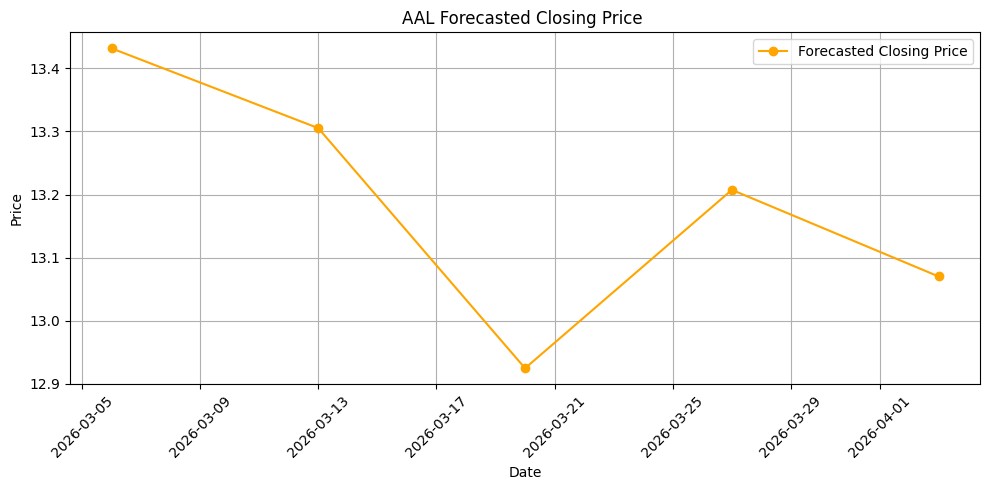

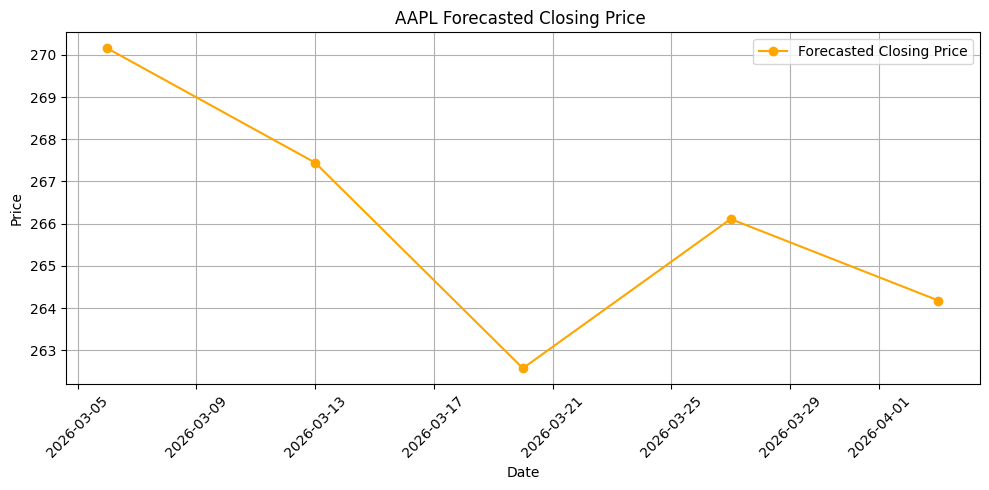

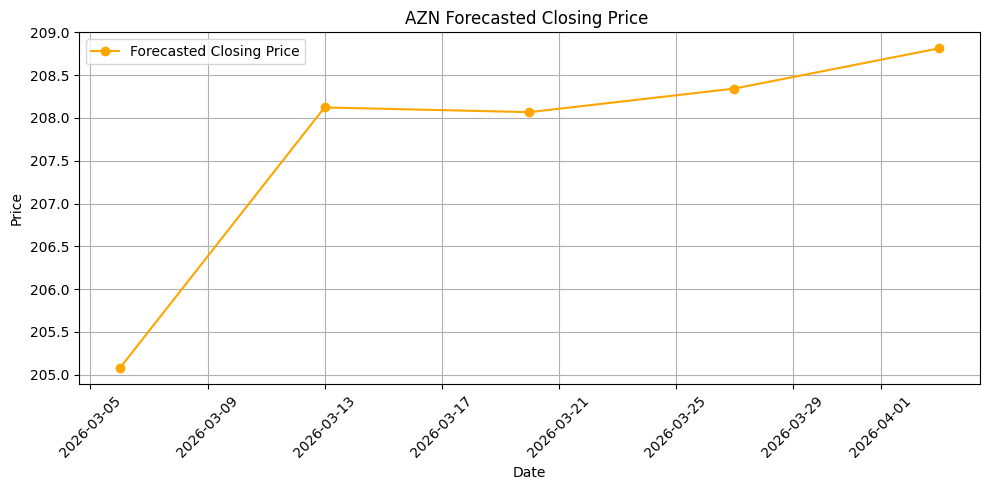

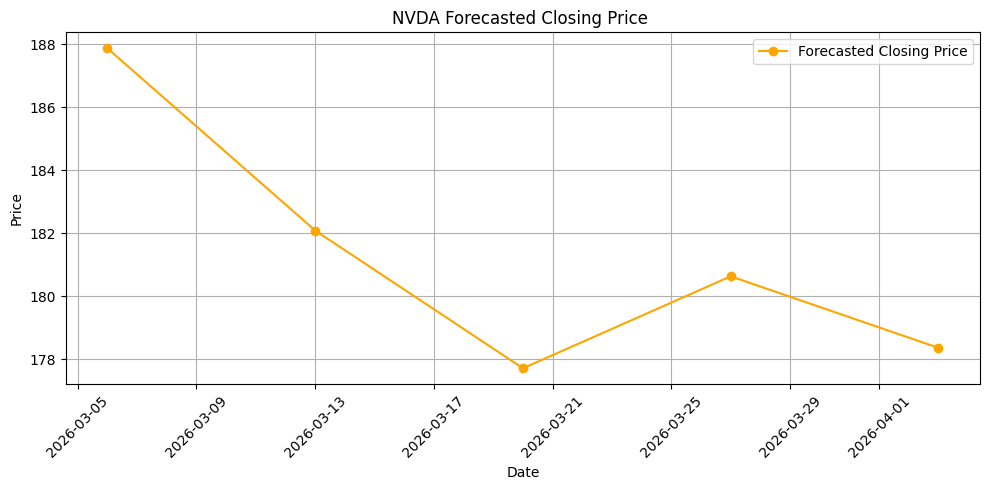

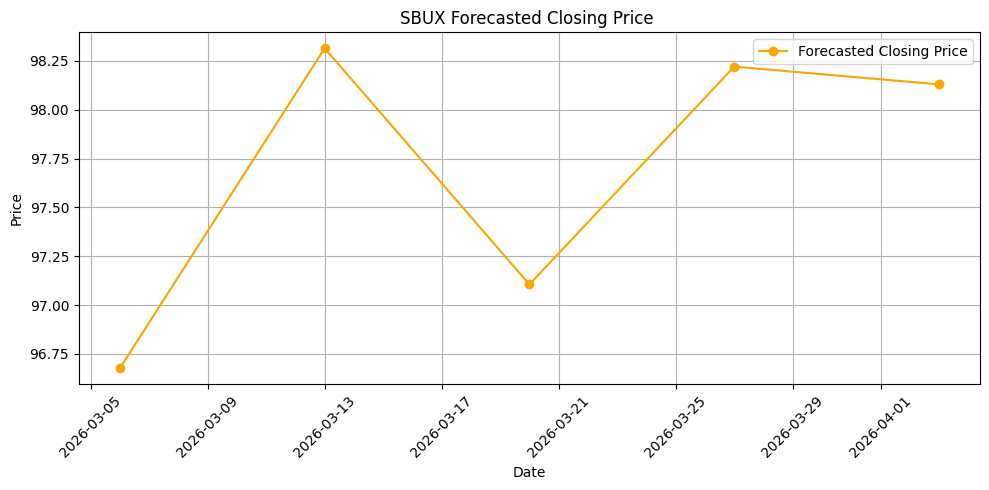

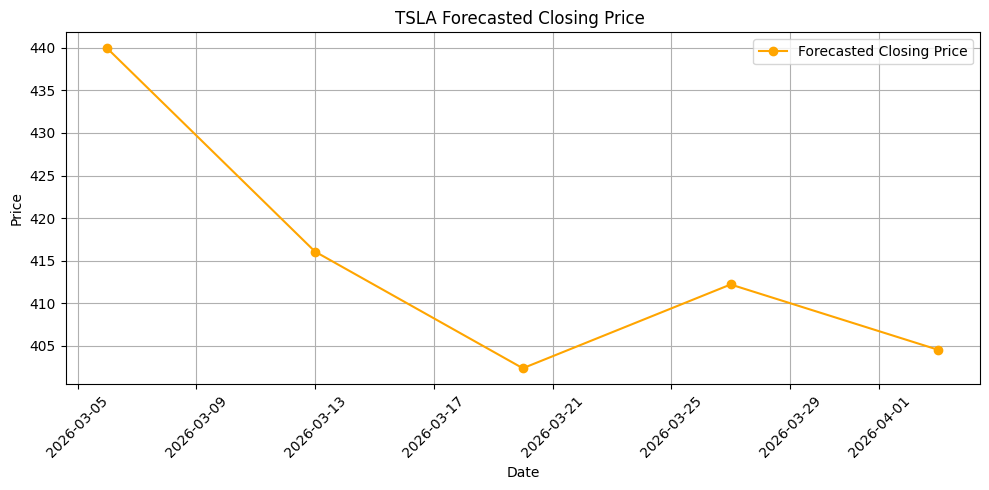

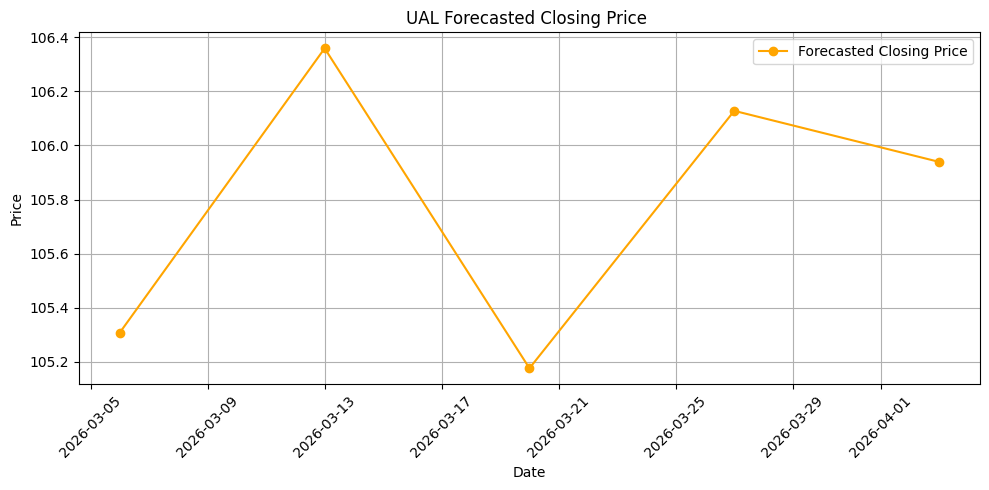

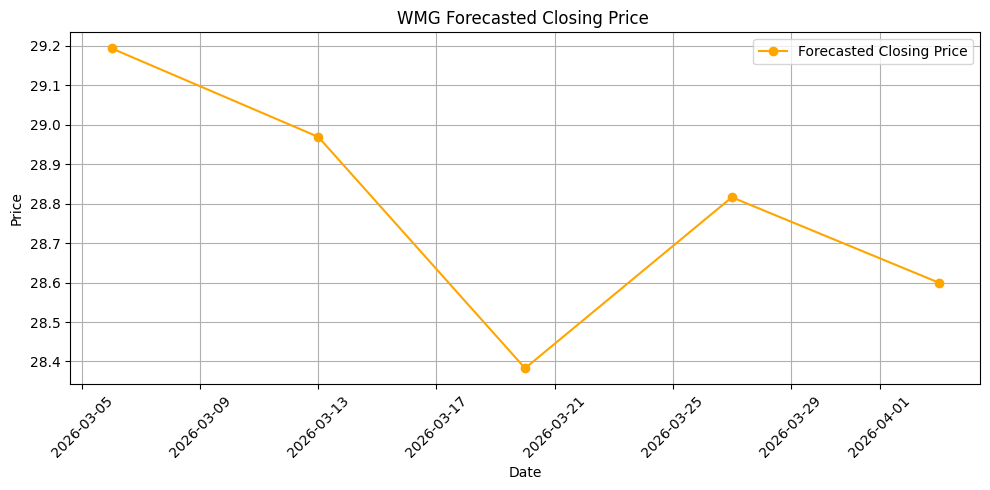

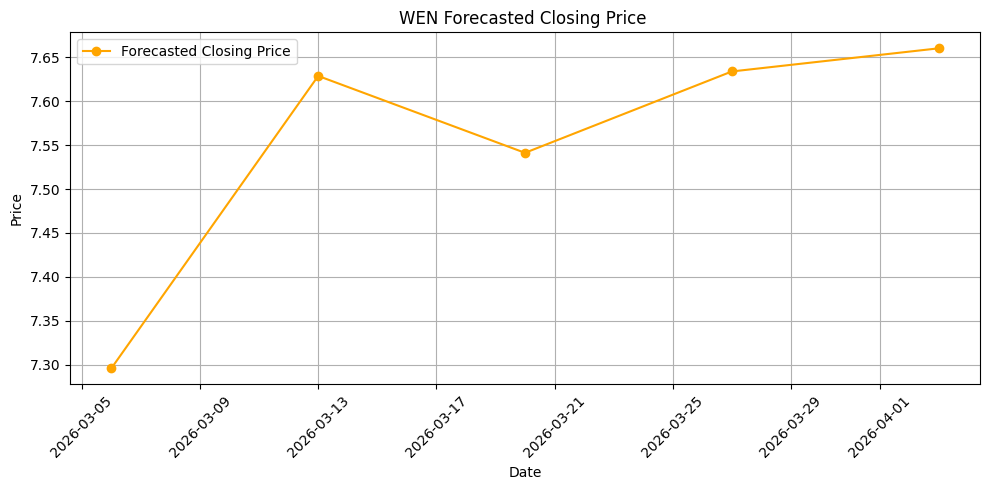

In [50]:
import matplotlib.pyplot as plt
import pandas as pd

requested_dates = pd.to_datetime([
    '2026-03-06',
    '2026-03-13',
    '2026-03-20',
    '2026-03-27',
    '2026-04-03'
])

# Plot the 5-week forecast for each company
for ticker, res in results.items():
    # Filter the forecast for the specific dates
    filtered_forecast = res['forecast_5weeks'][res['forecast_5weeks'].index.isin(requested_dates)]

    if not filtered_forecast.empty:
        plt.figure(figsize=(10, 5))
        plt.plot(filtered_forecast.index, filtered_forecast.values, marker='o', linestyle='-', color='orange', label='Forecasted Closing Price')
        plt.title(f"{ticker} Forecasted Closing Price ")
        plt.xlabel("Date")
        plt.ylabel("Price")
        plt.xticks(rotation=45)
        plt.grid(True)
        plt.legend()
        plt.tight_layout()
        plt.show()
    else:
        print(f"No forecast data for {ticker} available on the specified dates.")

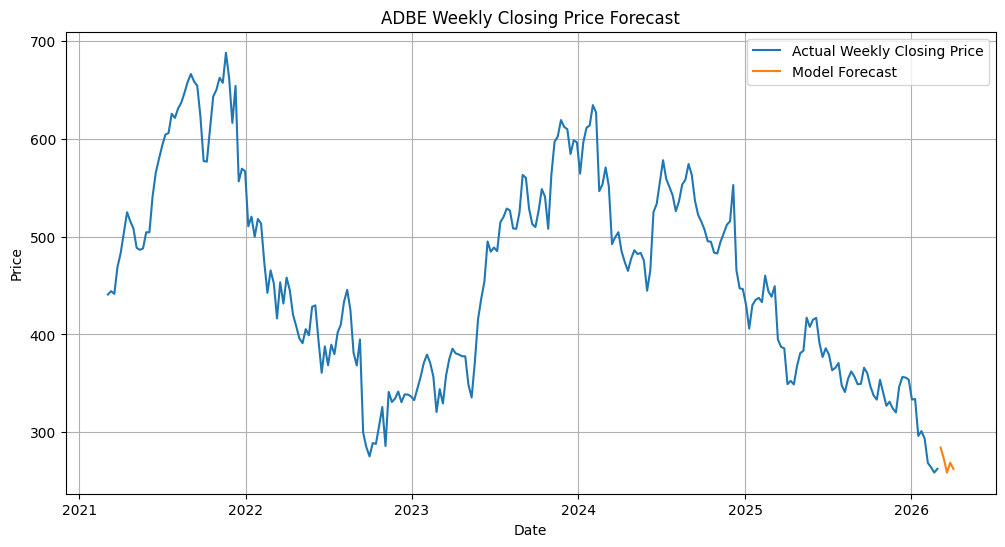

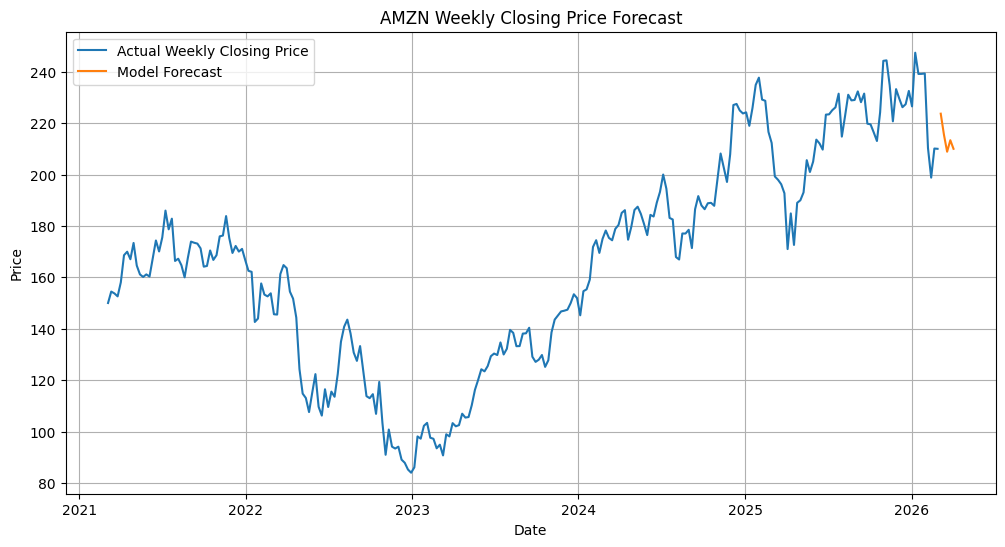

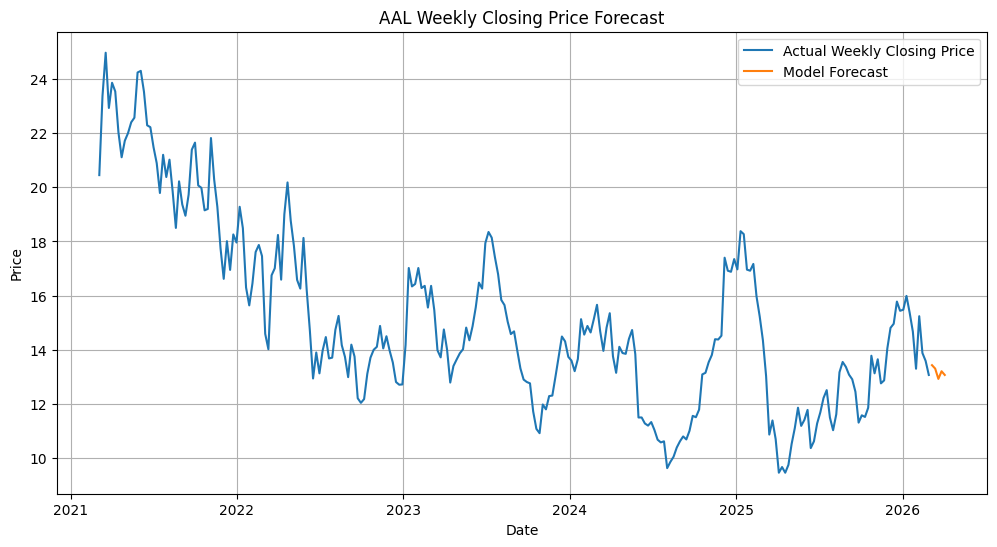

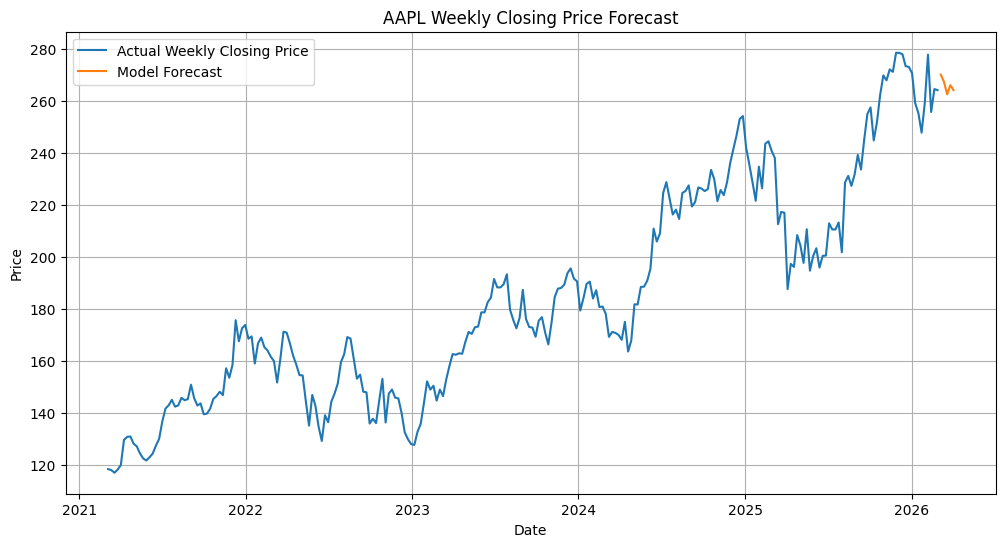

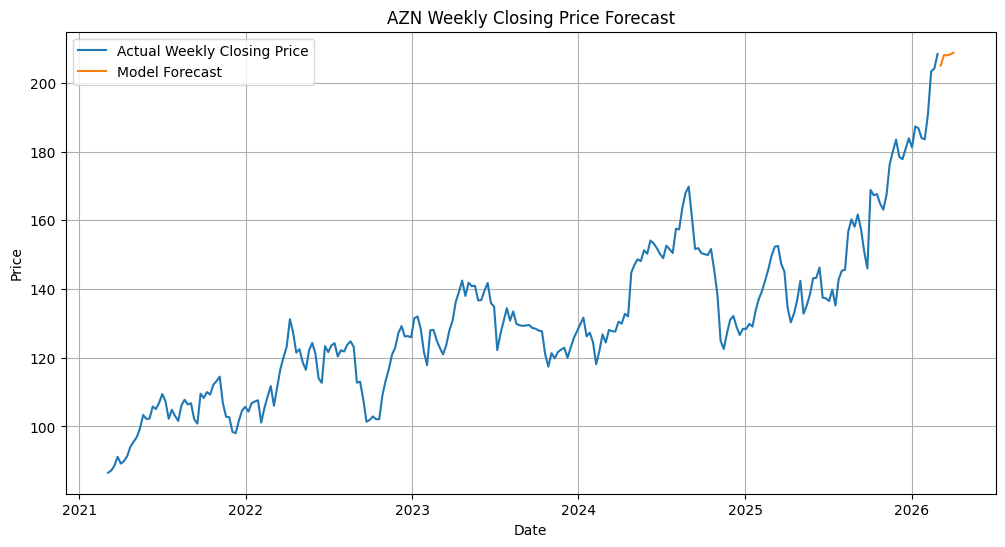

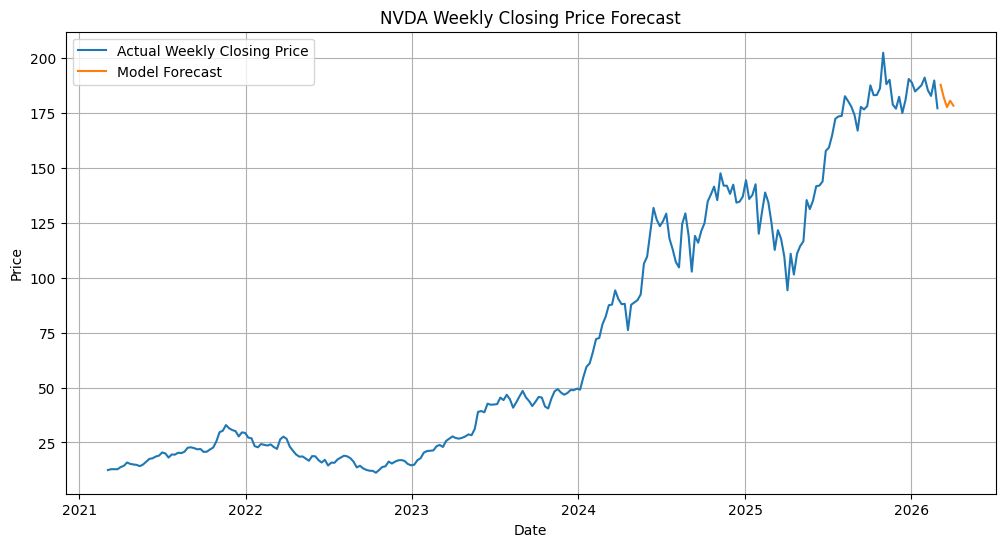

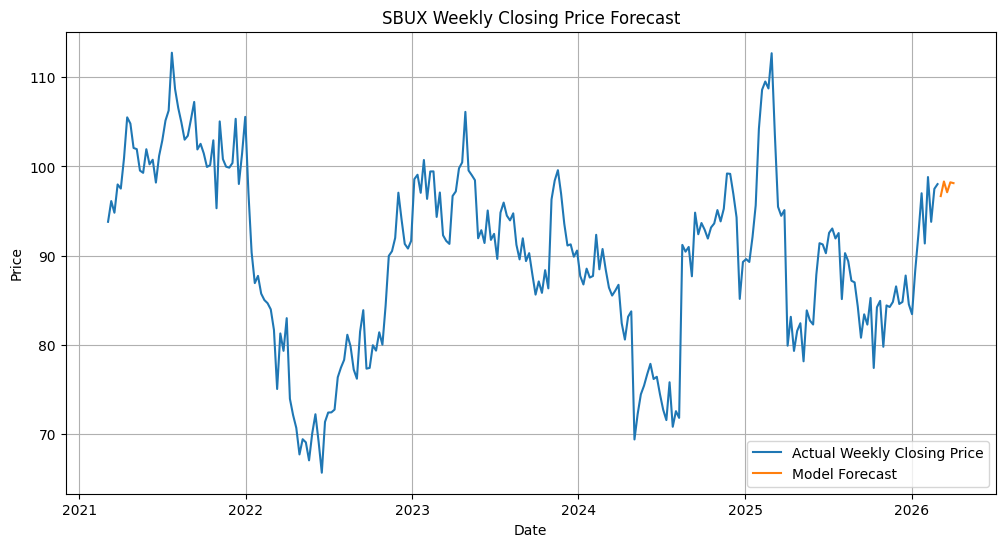

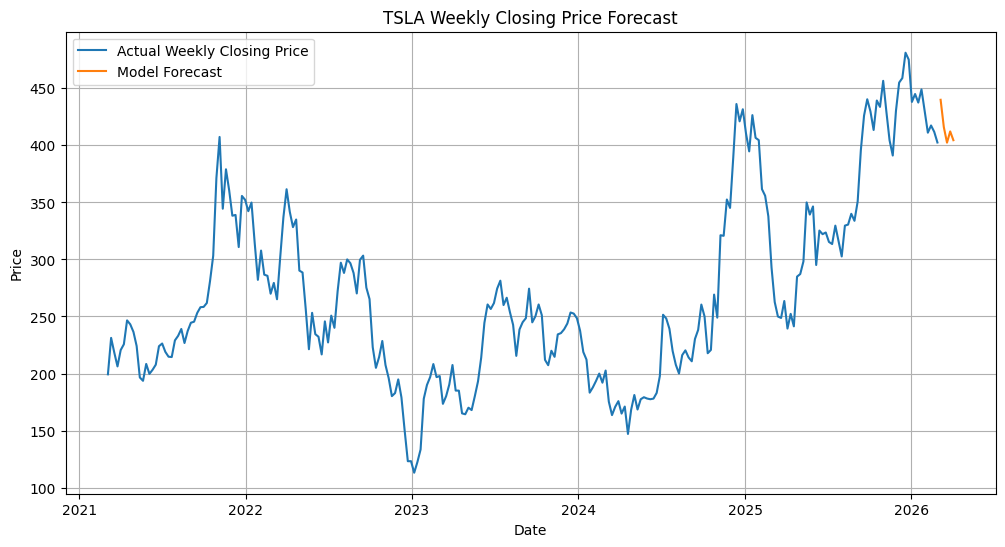

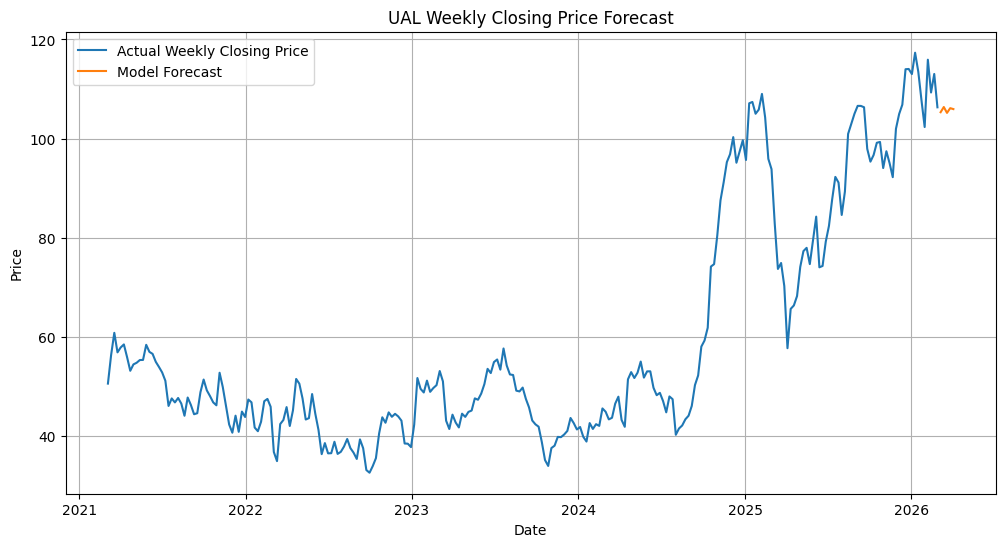

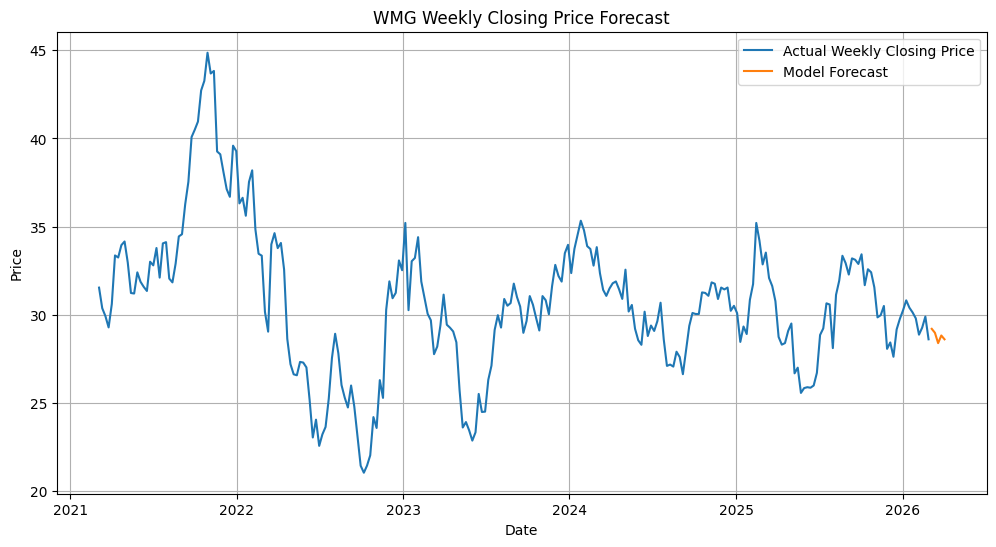

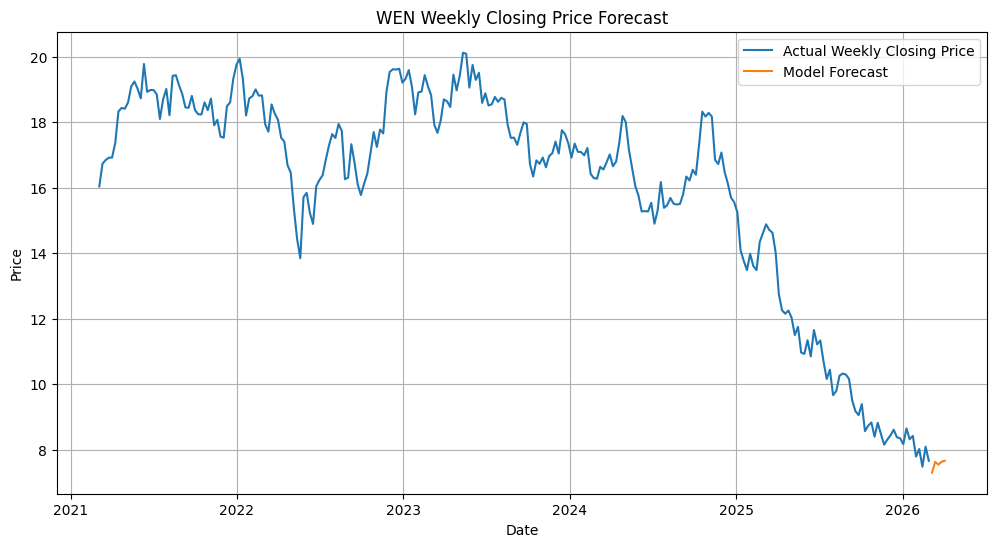

In [51]:
import matplotlib.pyplot as plt

# Plot for all companies

for ticker in tickers:
    ts = data[ticker]

    plt.figure(figsize=(12, 6))
    plt.plot(ts, label='Actual Weekly Closing Price')

    # Check if 'forecast_5weeks_model' exists, otherwise use 'forecast_5weeks'
    if 'forecast_5weeks_model' in results[ticker]:
        plt.plot(results[ticker]['forecast_5weeks_model'], label='Model Forecast')
    elif 'forecast_5weeks' in results[ticker]:
        plt.plot(results[ticker]['forecast_5weeks'], label='Model Forecast')

    plt.title(f"{ticker} Weekly Closing Price Forecast")
    plt.xlabel("Date")
    plt.ylabel("Price")
    plt.legend()
    plt.grid(True)
    plt.show()

#**Model 2 - Human Adjustment**

In [52]:
import yfinance as yf
import pandas as pd
from datetime import datetime, timedelta

# Stock tickers
stocks = {
    "Adobe": "ADBE",
    "AstraZeneca": "AZN",
    "Amazon": "AMZN",
    "American Airlines": "AAL",
    "Apple": "AAPL",
    "Nvidia": "NVDA",
    "Starbucks": "SBUX",
    "Tesla": "TSLA",
    "United Airlines": "UAL",
    "Warner Music Group": "WMG",
    "Wendy's Company": "WEN"
}

today = datetime.today()

# Time periods
periods = {
    "1D": today - timedelta(days=1),
    "5D": today - timedelta(days=5),
    "1 Month": today - timedelta(days=30),
    "6 Months": today - timedelta(days=182),
    "YTD": datetime(today.year,1,1),
    "1 Year": today - timedelta(days=365)
}

# Download market indicators
market = yf.download(["^GSPC","^IXIC","^VIX"], period="1y", progress=False)

results = []

for company, ticker_symbol in stocks.items(): # Renamed 'ticker' to 'ticker_symbol' to avoid confusion

    # Renamed 'data' to 'stock_daily_df' to avoid overwriting the 'data' dictionary from cell eCESbgH3j0hJ
    stock_daily_df = yf.download(ticker_symbol, period="1y", progress=False)

    # Feature Engineering
    stock_daily_df["Daily Return"] = stock_daily_df["Close"].pct_change()
    stock_daily_df["MA20"] = stock_daily_df["Close"].rolling(20).mean()
    stock_daily_df["MA50"] = stock_daily_df["Close"].rolling(50).mean()
    stock_daily_df["Volatility_5D"] = stock_daily_df["Daily Return"].rolling(5).std()
    stock_daily_df["Momentum_10D"] = stock_daily_df["Close"] - stock_daily_df["Close"].shift(10)
    stock_daily_df["High_Low_Spread"] = stock_daily_df["High"] - stock_daily_df["Low"]
    stock_daily_df["Open_Close_Spread"] = stock_daily_df["Open"] - stock_daily_df["Close"]

    for period_name, start_date in periods.items():

        period_data = stock_daily_df[stock_daily_df.index >= start_date]

        if len(period_data) == 0:
            continue

        open_price = period_data["Open"].iloc[0]
        close_price = period_data["Close"].iloc[-1]
        high_price = period_data["High"].max()
        volume = period_data["Volume"].sum()
        pct_return = ((close_price - open_price) / open_price) * 100

        sp500_return = market["Close"]["^GSPC"].pct_change().iloc[-1]
        nasdaq_return = market["Close"]["^IXIC"].pct_change().iloc[-1]
        vix_level = market["Close"]["^VIX"].iloc[-1]

        results.append({
            "Company": company,
            "Ticker": ticker_symbol, # Use the correct stock ticker symbol here
            "Period": period_name,
            "Opening Price": open_price,
            "Closing Price": close_price,
            "Highest Price": high_price,
            "Volume Traded": volume,
            "% Return": pct_return,
            "MA20": period_data["MA20"].iloc[-1],
            "MA50": period_data["MA50"].iloc[-1],
            "5D Volatility": period_data["Volatility_5D"].iloc[-1],
            "Momentum_10D": period_data["Momentum_10D"].iloc[-1],
            "High_Low_Spread": period_data["High_Low_Spread"].iloc[-1],
            "Open_Close_Spread": period_data["Open_Close_Spread"].iloc[-1],
            "SP500_Return": sp500_return,
            "NASDAQ_Return": nasdaq_return,
            "VIX_Level": vix_level
        })

# Store everything in a DataFrame for modeling
stock_prediction_df = pd.DataFrame(results)

# Sort for readability
stock_prediction_df = stock_prediction_df.sort_values(["Company","Period"])

# Display
print(stock_prediction_df)

/tmp/ipython-input-233/3054696840.py:33: FutureWarning: YF.download() has changed argument auto_adjust default to True
  market = yf.download(["^GSPC","^IXIC","^VIX"], period="1y", progress=False)
/tmp/ipython-input-233/3054696840.py:40: FutureWarning: YF.download() has changed argument auto_adjust default to True
  stock_daily_df = yf.download(ticker_symbol, period="1y", progress=False)
/tmp/ipython-input-233/3054696840.py:40: FutureWarning: YF.download() has changed argument auto_adjust default to True
  stock_daily_df = yf.download(ticker_symbol, period="1y", progress=False)
/tmp/ipython-input-233/3054696840.py:40: FutureWarning: YF.download() has changed argument auto_adjust default to True
  stock_daily_df = yf.download(ticker_symbol, period="1y", progress=False)
/tmp/ipython-input-233/3054696840.py:40: FutureWarning: YF.download() has changed argument auto_adjust default to True
  stock_daily_df = yf.download(ticker_symbol, period="1y", progress=False)
/tmp/ipython-input-233/3054

               Company Ticker    Period  \
1                Adobe   ADBE   1 Month   
4                Adobe   ADBE    1 Year   
0                Adobe   ADBE        5D   
2                Adobe   ADBE  6 Months   
3                Adobe   ADBE       YTD   
11              Amazon   AMZN   1 Month   
14              Amazon   AMZN    1 Year   
10              Amazon   AMZN        5D   
12              Amazon   AMZN  6 Months   
13              Amazon   AMZN       YTD   
16   American Airlines    AAL   1 Month   
19   American Airlines    AAL    1 Year   
15   American Airlines    AAL        5D   
17   American Airlines    AAL  6 Months   
18   American Airlines    AAL       YTD   
21               Apple   AAPL   1 Month   
24               Apple   AAPL    1 Year   
20               Apple   AAPL        5D   
22               Apple   AAPL  6 Months   
23               Apple   AAPL       YTD   
6          AstraZeneca    AZN   1 Month   
9          AstraZeneca    AZN    1 Year   
5          

In [53]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt

# -----------------------------
# Use your stock_prediction_df
# -----------------------------
# Example: stock_prediction_df from previous script
df = stock_prediction_df.copy()

# Fix: Convert columns containing Series objects to scalar numeric values
# Identify columns that are currently 'object' type but should be numeric
object_cols_to_numeric = [
    "Opening Price", "Closing Price", "Highest Price", "Volume Traded", "% Return",
    "MA20", "MA50", "5D Volatility", "Momentum_10D", "High_Low_Spread",
    "Open_Close_Spread", "SP500_Return", "NASDAQ_Return", "VIX_Level"
]

for col in object_cols_to_numeric:
    if col in df.columns:
        # Check if the column contains pandas Series objects and extract the scalar
        # This approach assumes each Series in the column has a single item
        # If an item is already a number (e.g., from other calculations), it will remain as is
        try:
            df[col] = df[col].apply(lambda x: x.item() if isinstance(x, (pd.Series, np.ndarray)) and x.size == 1 else x)
        except AttributeError:
            # Handle cases where x might not have .item() (e.g., if it's a direct scalar already)
            pass
        # Finally, convert the column to numeric, coercing errors
        df[col] = pd.to_numeric(df[col], errors='coerce')

# Drop rows with NaN values introduced by coercion or from original feature engineering
df.dropna(subset=object_cols_to_numeric, inplace=True)


# -----------------------------
# Prepare features (X) and target (y)
# -----------------------------
# Define feature columns
feature_cols = [
    "Opening Price","Highest Price","Volume Traded","% Return",
    "MA20","MA50","5D Volatility","Momentum_10D",
    "High_Low_Spread","Open_Close_Spread",
    "SP500_Return","NASDAQ_Return","VIX_Level"
]

X = df[feature_cols]

# Target: predict next period Closing Price
# Sort by Company and Period to ensure correct shifting for each stock
df = df.sort_values(by=["Company", "Period"]) # Ensure sorting is correct

y = df.groupby("Ticker")["Closing Price"].shift(-1)

# Drop rows where y is NaN (i.e., the last entry for each stock, which has no 'next' closing price)
valid_idx = y.dropna().index
X = X.loc[valid_idx]
y = y.loc[valid_idx]

# -----------------------------
# Split data into train/test 80/20
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=True, random_state=42)

# -----------------------------
# Train XGBoost Regressor
# -----------------------------
xgb_model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

xgb_model.fit(X_train, y_train)

# -----------------------------
# Evaluate model
# -----------------------------
y_pred = xgb_model.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f"Test RMSE: {rmse:.2f}")

Test RMSE: 9.85



Feature Importance:
              Feature  Importance
1       Highest Price    0.310677
4                MA20    0.216347
0       Opening Price    0.208027
5                MA50    0.196264
7        Momentum_10D    0.067764
6       5D Volatility    0.000551
3            % Return    0.000144
9   Open_Close_Spread    0.000140
2       Volume Traded    0.000060
8     High_Low_Spread    0.000026
10       SP500_Return    0.000000
11      NASDAQ_Return    0.000000
12          VIX_Level    0.000000


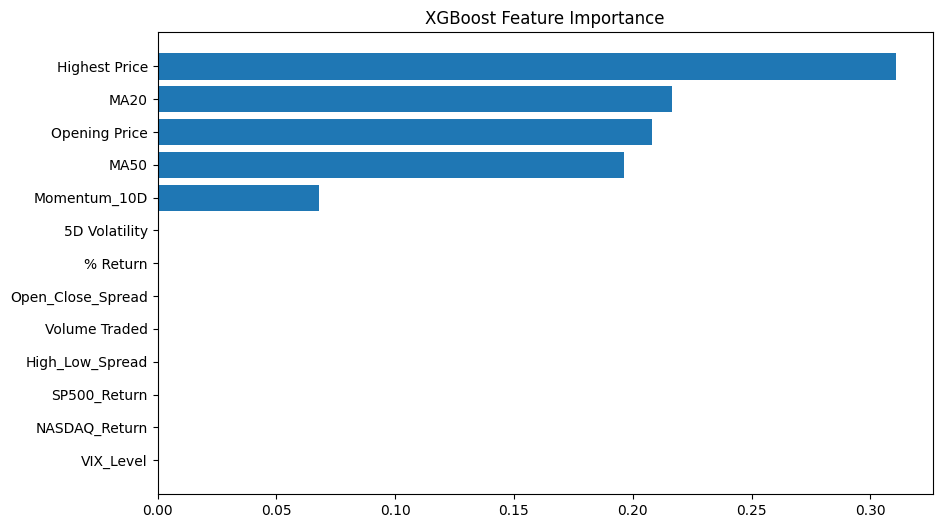

In [54]:
# -----------------------------
# Feature Importance
# -----------------------------
importance = pd.DataFrame({
    "Feature": feature_cols,
    "Importance": xgb_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

print("\nFeature Importance:")
print(importance)

# Optional: plot
plt.figure(figsize=(10,6))
plt.barh(importance["Feature"], importance["Importance"])
plt.gca().invert_yaxis()
plt.title("XGBoost Feature Importance")
plt.show()

In [55]:
import pandas as pd
import numpy as np

# Make a copy of stock_prediction_df
processed_stock_df = stock_prediction_df.copy()

# Define a list named columns_to_numeric
columns_to_numeric = [
    'Opening Price', 'Closing Price', 'Highest Price', 'Volume Traded', '% Return',
    'MA20', 'MA50', '5D Volatility', 'Momentum_10D', 'High_Low_Spread',
    'Open_Close_Spread', 'SP500_Return', 'NASDAQ_Return', 'VIX_Level'
]

# Iterate through each column to convert Series/ndarray items to scalars
for col in columns_to_numeric:
    if col in processed_stock_df.columns:
        try:
            # Apply lambda to extract scalar from Series/ndarray, or keep as is
            processed_stock_df[col] = processed_stock_df[col].apply(lambda x: x.item() if isinstance(x, (pd.Series, np.ndarray)) and x.size == 1 else x)
        except AttributeError:
            # Handle cases where x might not have .item() (e.g., if it's already a scalar)
            pass

# Convert the columns to a numeric data type, coercing errors to NaN
for col in columns_to_numeric:
    if col in processed_stock_df.columns:
        processed_stock_df[col] = pd.to_numeric(processed_stock_df[col], errors='coerce')

# Remove any rows from processed_stock_df that have NaN values in the specified columns
processed_stock_df.dropna(subset=columns_to_numeric, inplace=True)

print("Processed stock_prediction_df info:")
processed_stock_df.info()
print("\nFirst 5 rows of processed_stock_df:")
print(processed_stock_df.head())

Processed stock_prediction_df info:
<class 'pandas.core.frame.DataFrame'>
Index: 55 entries, 1 to 53
Data columns (total 17 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Company            55 non-null     object 
 1   Ticker             55 non-null     object 
 2   Period             55 non-null     object 
 3   Opening Price      55 non-null     float64
 4   Closing Price      55 non-null     float64
 5   Highest Price      55 non-null     float64
 6   Volume Traded      55 non-null     int64  
 7   % Return           55 non-null     float64
 8   MA20               55 non-null     float64
 9   MA50               55 non-null     float64
 10  5D Volatility      55 non-null     float64
 11  Momentum_10D       55 non-null     float64
 12  High_Low_Spread    55 non-null     float64
 13  Open_Close_Spread  55 non-null     float64
 14  SP500_Return       55 non-null     float64
 15  NASDAQ_Return      55 non-null     float64
 1

In [56]:
import pandas as pd
import numpy as np

weeks = 5
future_dates = pd.date_range(start="2026-03-06", periods=weeks, freq="7D")
future_predictions = []

# Last known market features (simplification)
# Ensure last_market also contains scalar values, derived from processed_stock_df
last_market = processed_stock_df.iloc[-1][["SP500_Return","NASDAQ_Return","VIX_Level"]]

feature_cols = [
    "Opening Price","Highest Price","Volume Traded","% Return",
    "MA20","MA50","5D Volatility","Momentum_10D",
    "High_Low_Spread","Open_Close_Spread",
    "SP500_Return","NASDAQ_Return","VIX_Level"
]

for ticker in processed_stock_df["Ticker"].unique():
    # Filter processed_stock_df to get stock_data for each ticker
    stock_data = processed_stock_df[processed_stock_df["Ticker"]==ticker].sort_values("Period")

    # Initialize last_row for each ticker by extracting the last row of stock_data
    last_row = stock_data.iloc[-1].copy()

    # Initialize rolling_prices for each ticker by extracting scalar 'Closing Price' values
    # from the last 50 entries of stock_data
    rolling_prices = stock_data["Closing Price"].tail(50).tolist()

    for week in range(weeks):
        # Create a new X_future for each forecast step
        X_future = pd.Series(index=feature_cols, dtype=float)

        # Update X_future's 'Opening Price' and 'Highest Price'
        # Initial 'Opening Price' for first forecast is the last known 'Closing Price'
        X_future["Opening Price"] = last_row["Closing Price"]
        # Highest Price can be estimated as Opening Price + High_Low_Spread
        X_future["Highest Price"] = X_future["Opening Price"] + last_row["High_Low_Spread"]

        # Volume Traded and % Return are difficult to forecast dynamically for a single week
        # Using last known values for simplicity or setting to average/zero for forecast
        X_future["Volume Traded"] = last_row["Volume Traded"]
        X_future["% Return"] = 0 # Assuming no return for simplicity, or can be derived

        # MA20 Calculation
        if len(rolling_prices) >= 20:
            X_future["MA20"] = np.mean(rolling_prices[-20:])
        else:
            X_future["MA20"] = np.mean(rolling_prices)

        # MA50 Calculation
        if len(rolling_prices) >= 50:
            X_future["MA50"] = np.mean(rolling_prices[-50:])
        else:
            X_future["MA50"] = np.mean(rolling_prices)

        # Momentum_10D Calculation
        if len(rolling_prices) >= 10:
            X_future["Momentum_10D"] = X_future["Opening Price"] - rolling_prices[-10]
        else:
            X_future["Momentum_10D"] = X_future["Opening Price"] - rolling_prices[0] if rolling_prices else 0

        # 5D Volatility Calculation
        if len(rolling_prices) >= 5:
            returns_5d = np.diff(rolling_prices[-5:]) / rolling_prices[-5:-1]
            # Handle potential division by zero or empty returns_5d
            if len(returns_5d) > 0:
                X_future["5D Volatility"] = np.std(returns_5d)
            else:
                X_future["5D Volatility"] = 0.0
        else:
            # Calculate volatility from all available prices if less than 5
            if len(rolling_prices) > 1:
                returns_all = np.diff(rolling_prices) / rolling_prices[:-1]
                X_future["5D Volatility"] = np.std(returns_all)
            else:
                X_future["5D Volatility"] = 0.0 # Not enough data for volatility

        # Spread & Market Features
        X_future["High_Low_Spread"] = last_row["High_Low_Spread"]
        X_future["Open_Close_Spread"] = 0 # For a forecast, assume open and close are close to prediction

        # Ensure last_market values are scalar when assigning
        X_future["SP500_Return"] = last_market["SP500_Return"]
        X_future["NASDAQ_Return"] = last_market["NASDAQ_Return"]
        X_future["VIX_Level"] = last_market["VIX_Level"]

        # Predict. The model expects a 2D array, so reshape X_future.
        pred_close_raw = xgb_model.predict(X_future.values.reshape(1,-1))[0]
        pred_close = float(pred_close_raw) # Ensure scalar

        future_predictions.append({
            "Ticker": ticker,
            "Predicted Date": future_dates[week],
            "Predicted Closing Price": pred_close
        })

        # Update for next week's iteration
        rolling_prices.append(pred_close)
        last_row["Opening Price"] = pred_close
        last_row["Closing Price"] = pred_close
        last_row["Highest Price"] = pred_close + last_row["High_Low_Spread"]

# Convert to DataFrame
future_df_dynamic = pd.DataFrame(future_predictions)
print("\nDynamic 5-Week Forecast:")
print(future_df_dynamic)


Dynamic 5-Week Forecast:
   Ticker Predicted Date  Predicted Closing Price
0    ADBE     2026-03-06               255.080109
1    ADBE     2026-03-13               254.663589
2    ADBE     2026-03-20               254.663589
3    ADBE     2026-03-27               254.663589
4    ADBE     2026-04-03               254.663589
5    AMZN     2026-03-06               209.190506
6    AMZN     2026-03-13               209.198044
7    AMZN     2026-03-20               209.198044
8    AMZN     2026-03-27               209.198044
9    AMZN     2026-04-03               209.198044
10    AAL     2026-03-06                 9.846104
11    AAL     2026-03-13                 8.074437
12    AAL     2026-03-20                 7.985472
13    AAL     2026-03-27                 7.985472
14    AAL     2026-04-03                 7.985472
15   AAPL     2026-03-06               253.006897
16   AAPL     2026-03-13               248.523178
17   AAPL     2026-03-20               248.187759
18   AAPL     2026-03-27

In [57]:
import pandas as pd
import numpy as np

# Copy your existing forecast
future_df_randomized = future_df_dynamic.copy()

# Set a seed for reproducibility
np.random.seed(42)

# Define sector sensitivity to geopolitical/oil shocks
sector_shock = {
    "AAL": 0.07,   # Airlines more sensitive
    "UAL": 0.07,
    "TSLA": 0.03,  # Consumer discretionary / EVs
    "SBUX": 0.03,
    "WEN": 0.02,
    "WMG": 0.02,
    "AMZN": 0.015, # Tech, moderate
    "NVDA": 0.015,
    "ADBE": 0.015,
    "AAPL": 0.02,
    "AZN": 0.01,   # Pharma less sensitive
}

# Apply randomized weekly changes
for ticker in future_df_randomized["Ticker"].unique():
    idx = future_df_randomized["Ticker"] == ticker
    prices = future_df_randomized.loc[idx, "Predicted Closing Price"].values
    shock = sector_shock.get(ticker, 0.02)  # default moderate 2% weekly variation

    for i in range(1, len(prices)):
        # Apply small random fluctuation based on historical trend + geopolitical sensitivity
        change_pct = np.random.normal(loc=0, scale=shock)
        prices[i] = prices[i-1] * (1 + change_pct)

    # Update the DataFrame
    future_df_randomized.loc[idx, "Predicted Closing Price"] = prices

# Round to 2 decimals for readability
future_df_randomized["Predicted Closing Price"] = future_df_randomized["Predicted Closing Price"].round(2)

print(future_df_randomized)

   Ticker Predicted Date  Predicted Closing Price
0    ADBE     2026-03-06                   255.08
1    ADBE     2026-03-13                   256.98
2    ADBE     2026-03-20                   256.45
3    ADBE     2026-03-27                   258.94
4    ADBE     2026-04-03                   264.85
5    AMZN     2026-03-06                   209.19
6    AMZN     2026-03-13                   208.46
7    AMZN     2026-03-20                   207.72
8    AMZN     2026-03-27                   212.64
9    AMZN     2026-04-03                   215.09
10    AAL     2026-03-06                     9.85
11    AAL     2026-03-13                     9.52
12    AAL     2026-03-20                     9.88
13    AAL     2026-03-27                     9.56
14    AAL     2026-04-03                     9.25
15   AAPL     2026-03-06                   253.01
16   AAPL     2026-03-13                   254.23
17   AAPL     2026-03-20                   244.50
18   AAPL     2026-03-27                   236.07


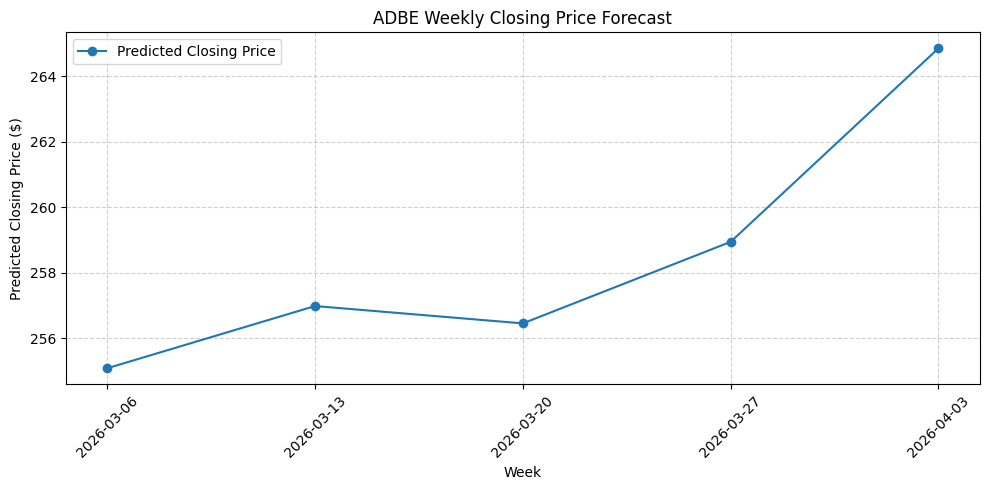

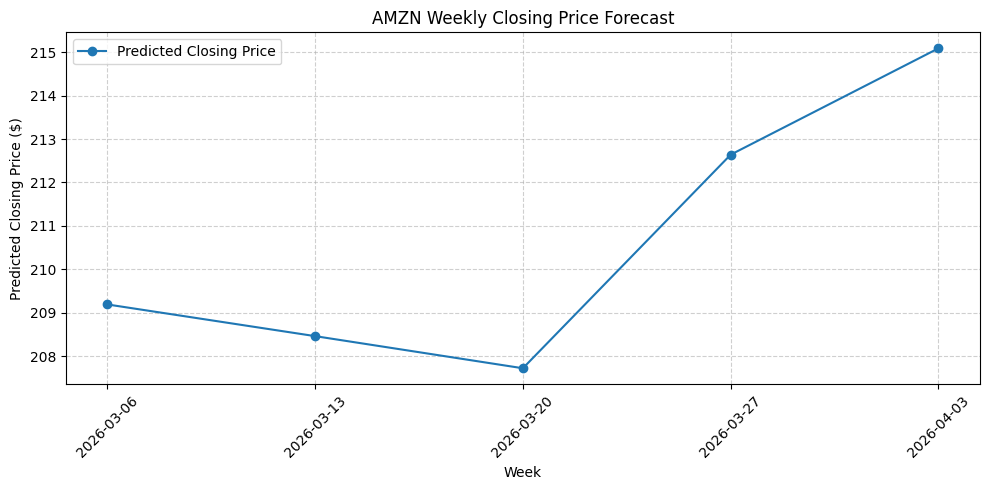

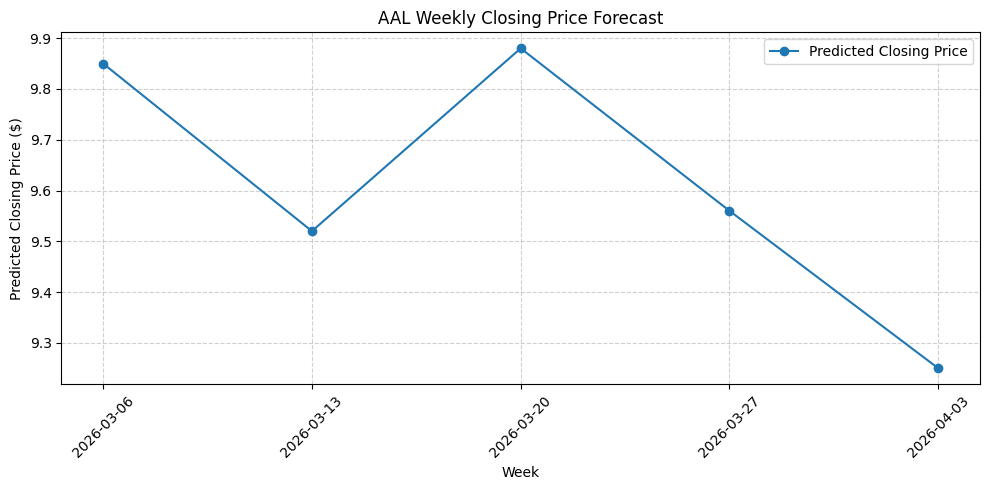

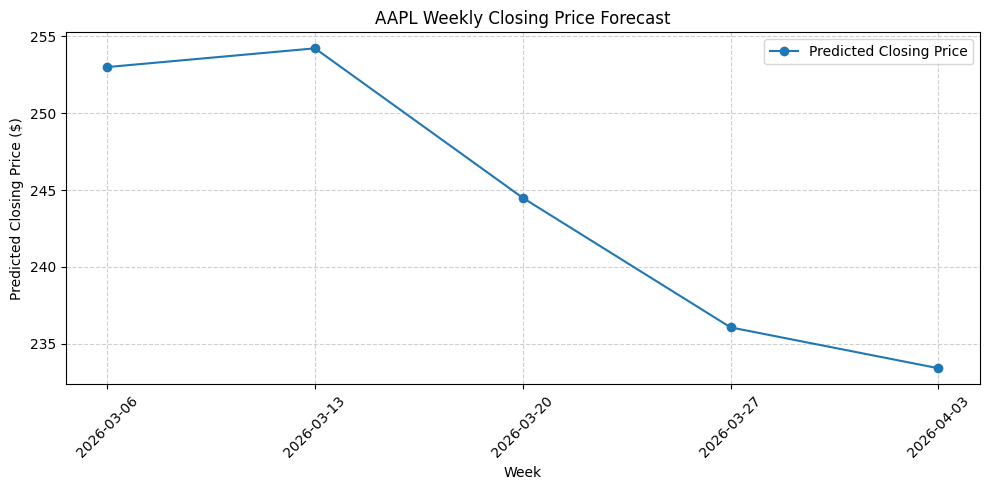

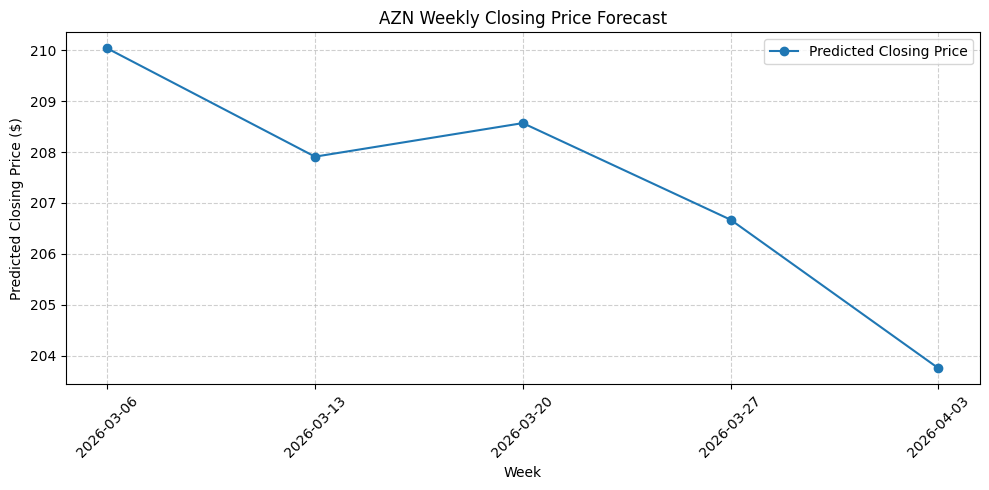

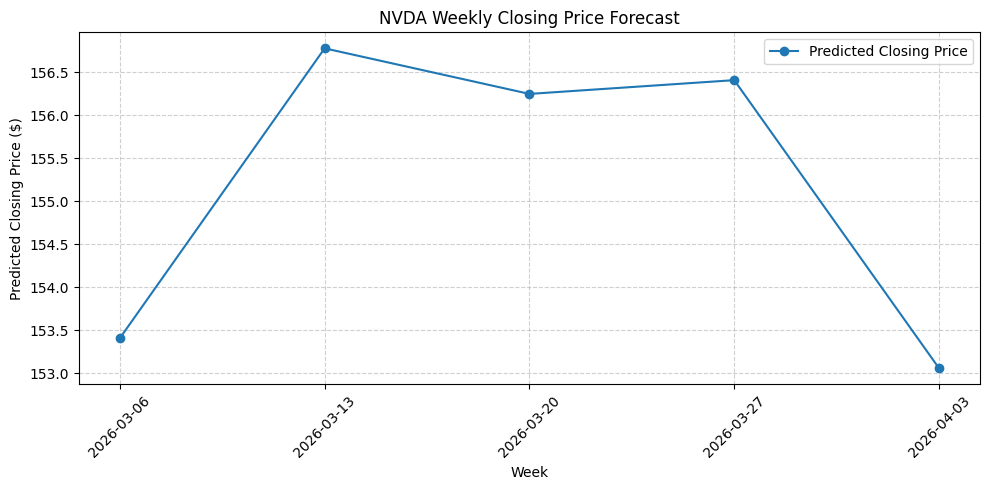

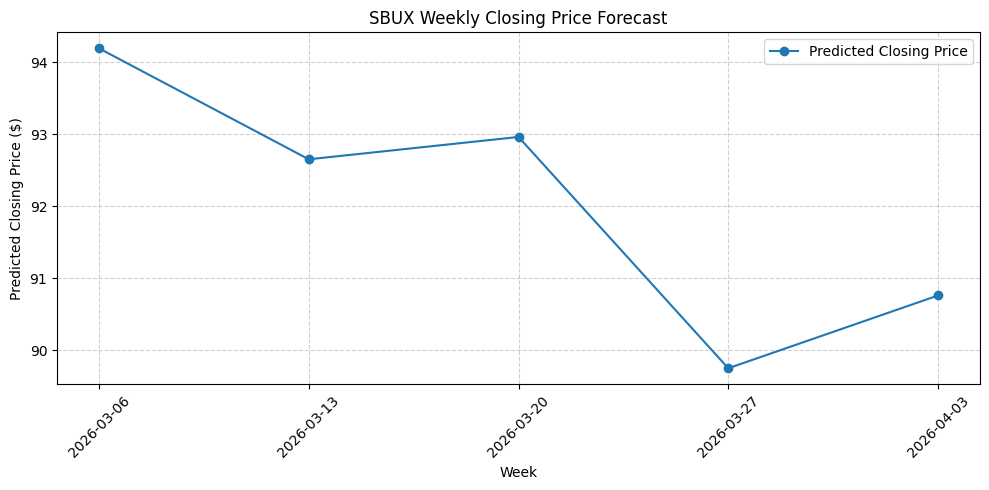

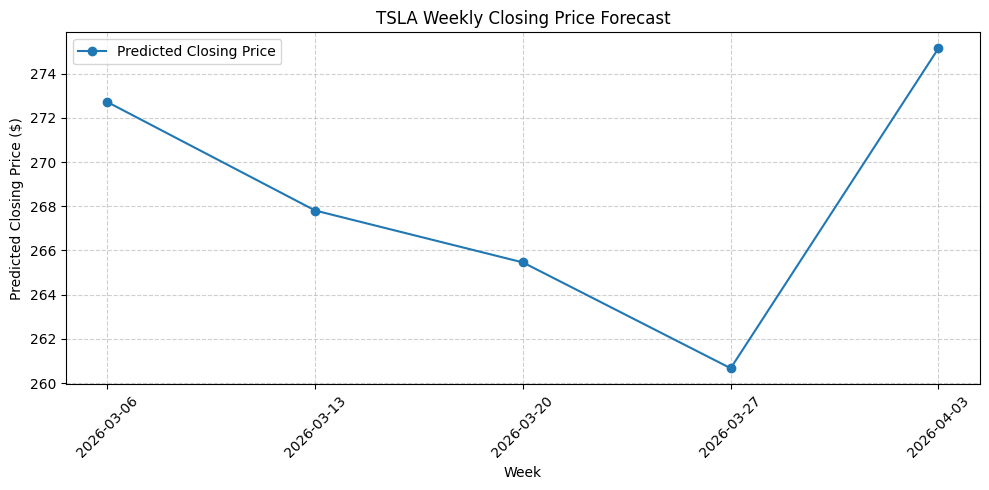

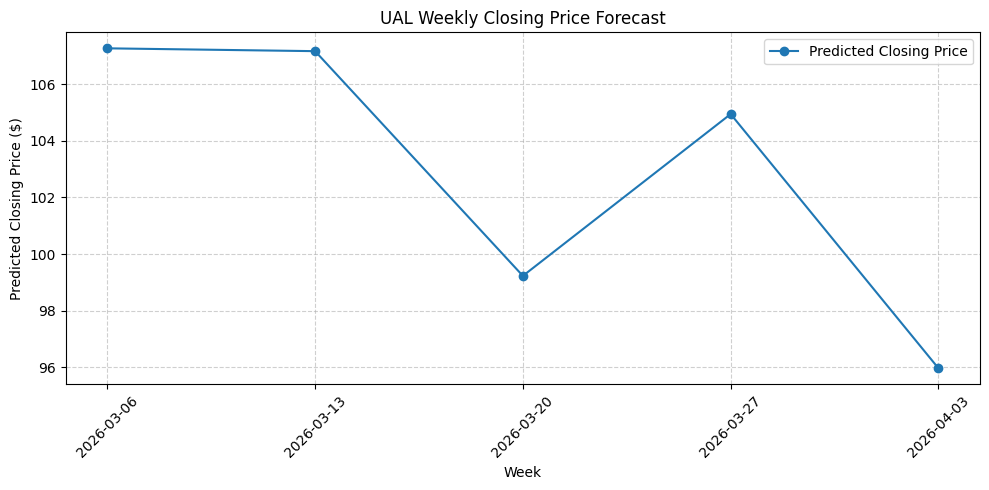

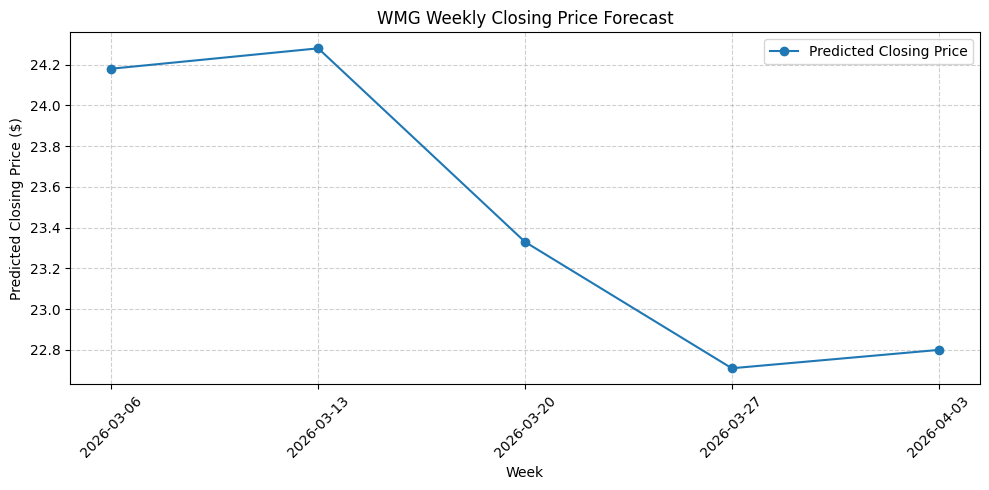

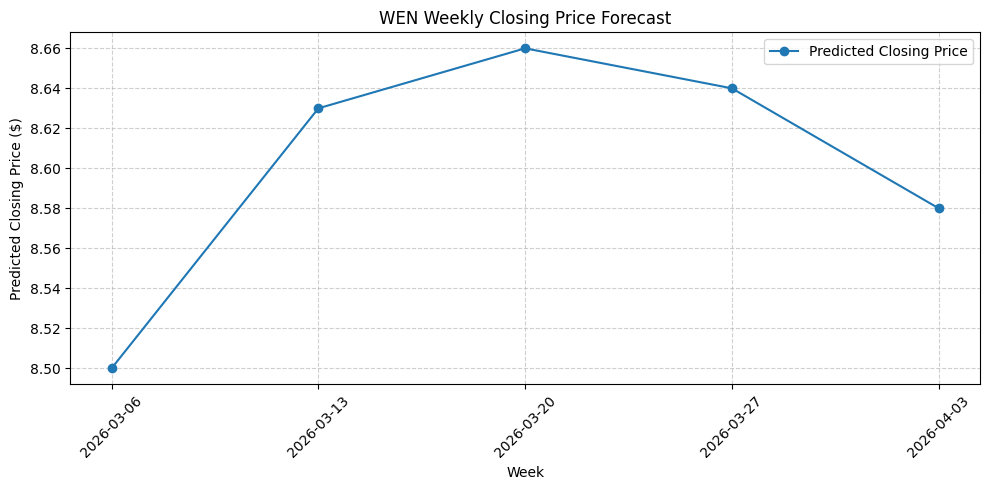

In [58]:
import matplotlib.pyplot as plt

# Ensure tickers are unique
tickers = future_df_randomized["Ticker"].unique()

# Plot each stock individually
for ticker in tickers:
    ts = future_df_randomized[future_df_randomized["Ticker"] == ticker]

    plt.figure(figsize=(10, 5))
    plt.plot(ts["Predicted Date"], ts["Predicted Closing Price"], marker='o', linestyle='-', label='Predicted Closing Price')

    plt.title(f"{ticker} Weekly Closing Price Forecast")
    plt.xlabel("Week")
    plt.ylabel("Predicted Closing Price ($)")
    plt.xticks(ts["Predicted Date"], rotation=45)  # Use your exact dates
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend()
    plt.tight_layout()
    plt.show()

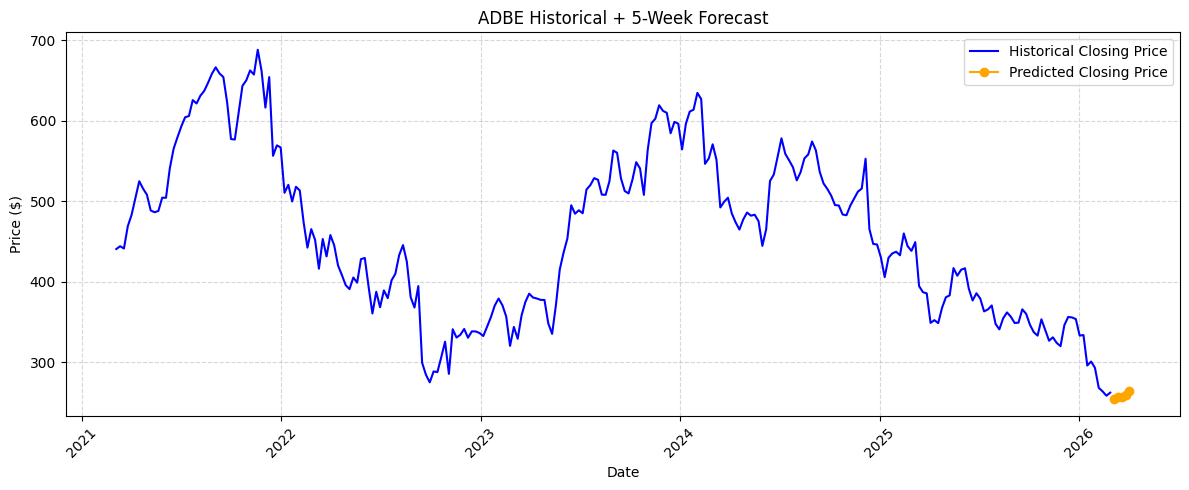

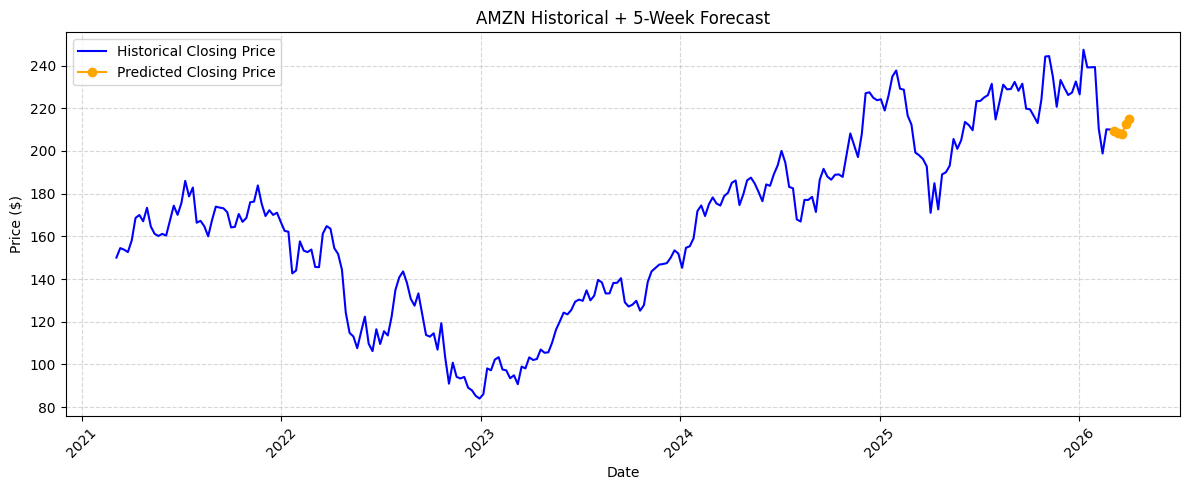

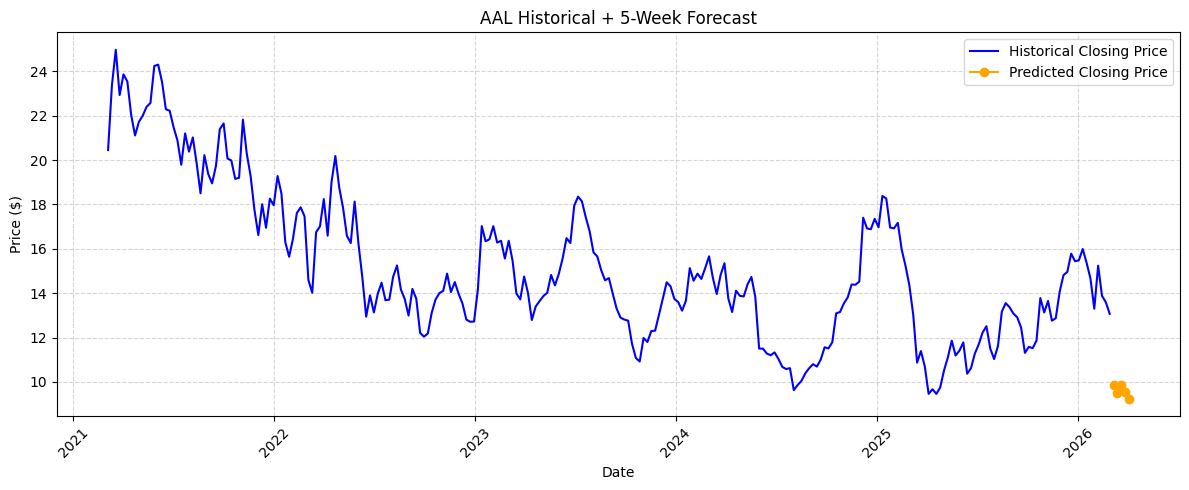

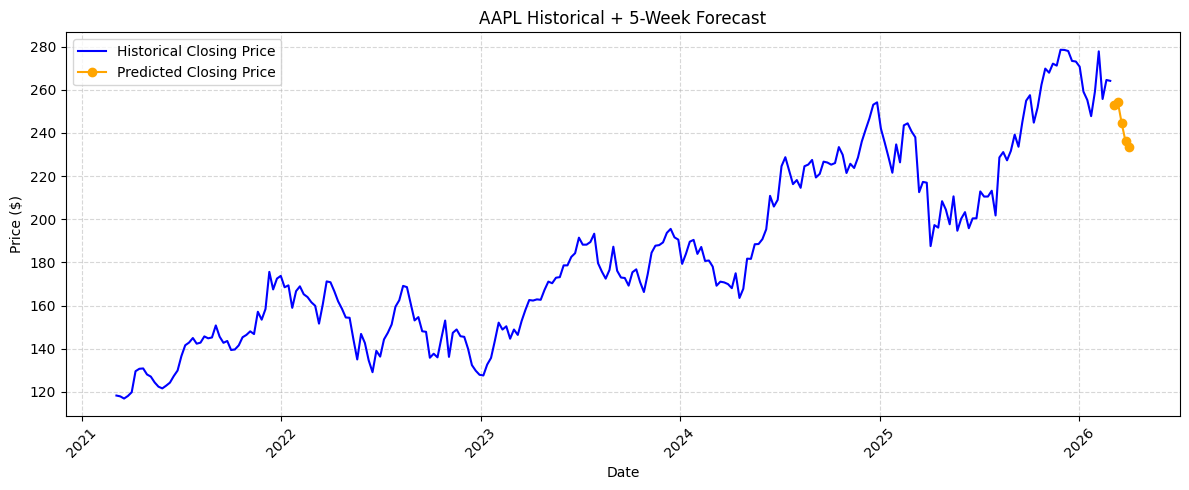

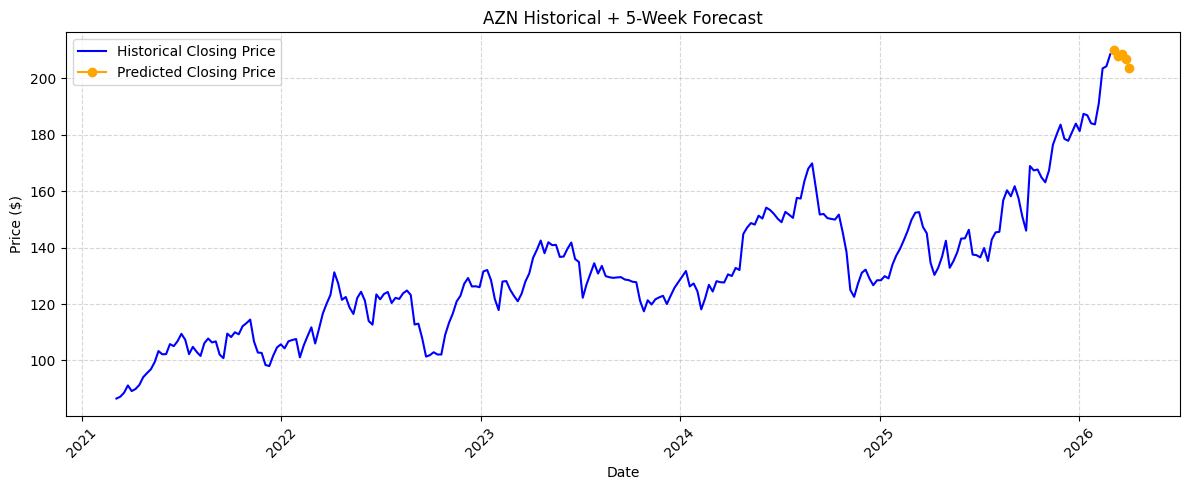

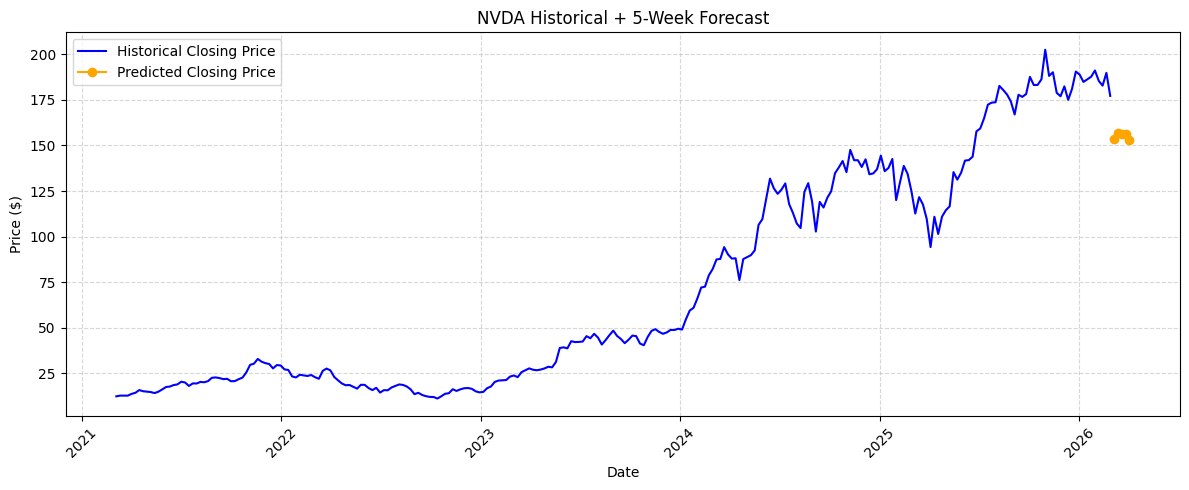

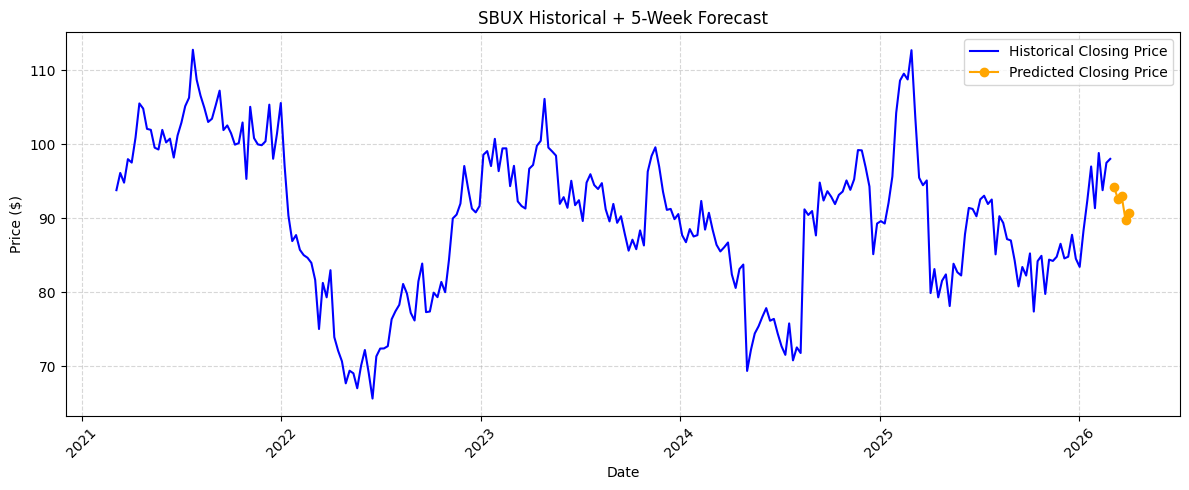

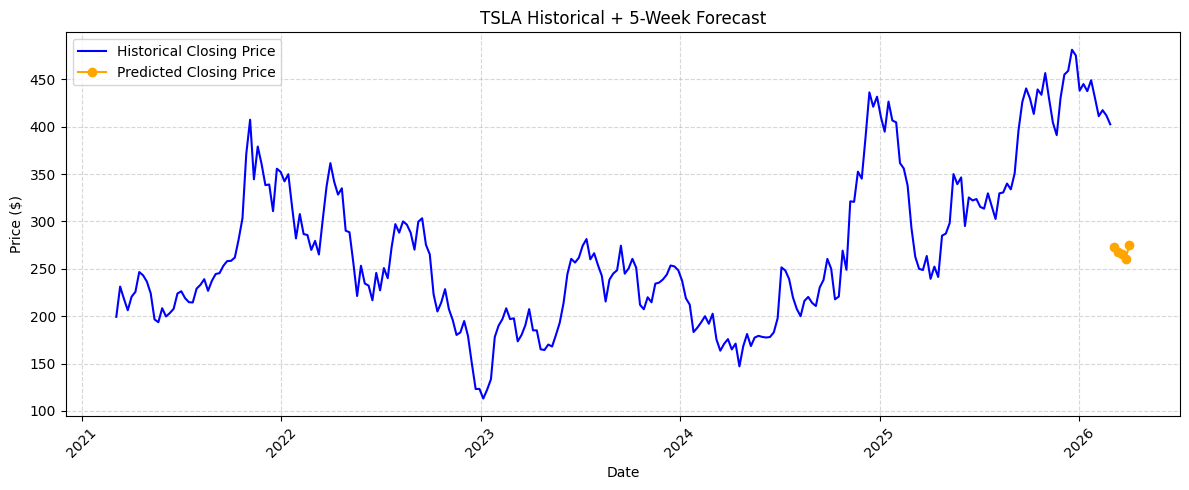

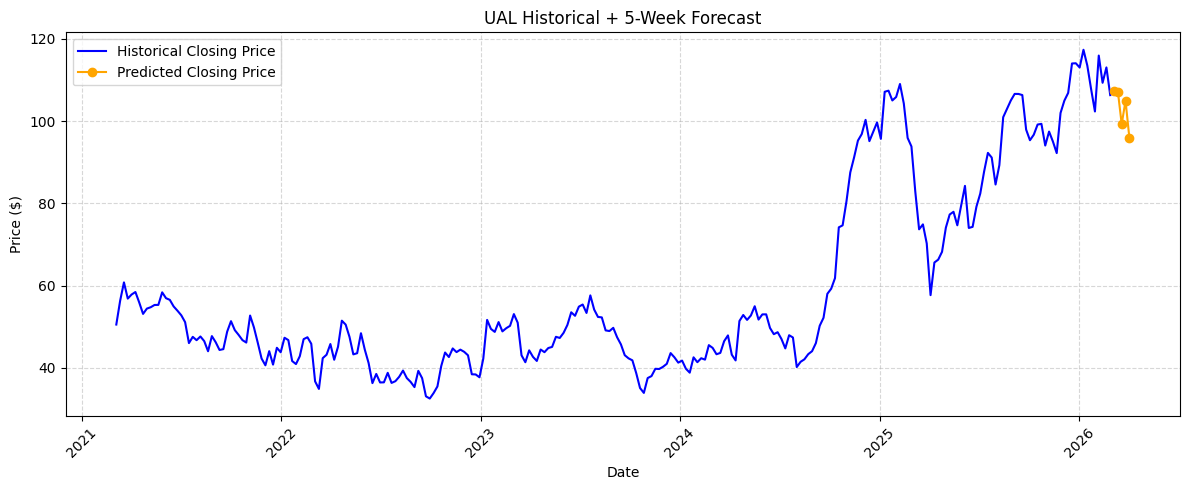

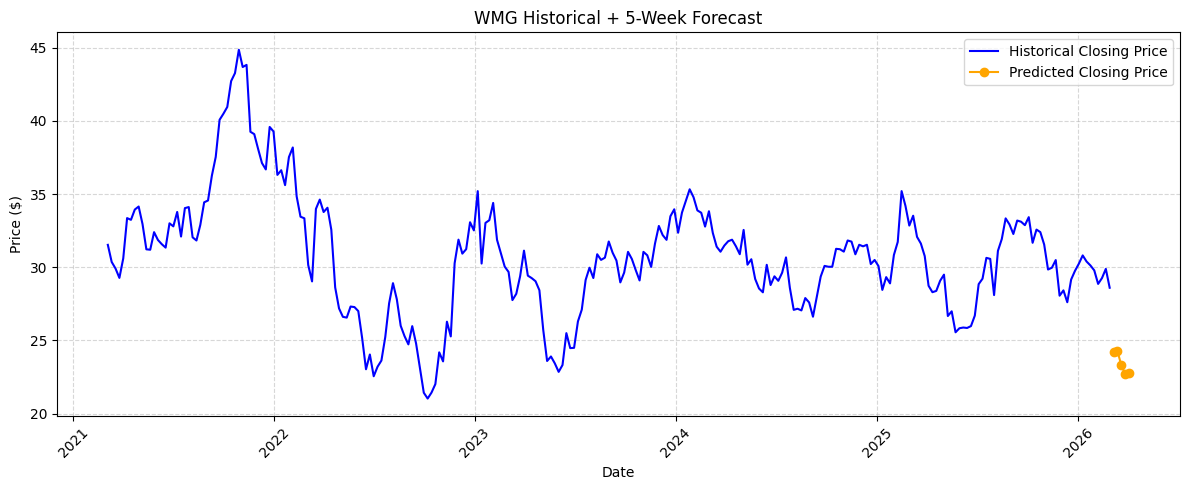

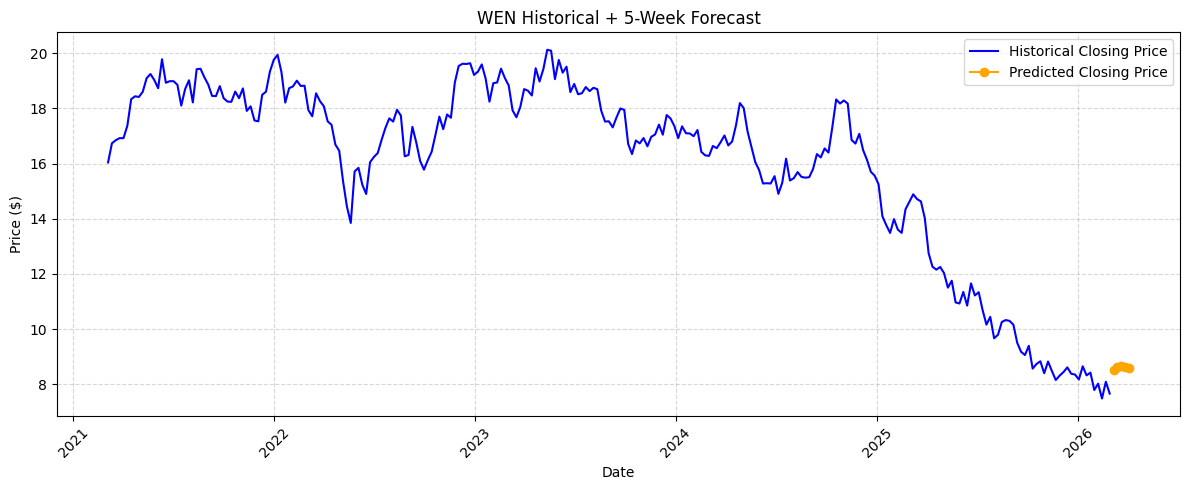

In [59]:
import matplotlib.pyplot as plt

# Create historical_df from the 'data' dictionary
historical_data_list = []
for ticker, series in data.items():
    # Skip NASDAQ and SP500 as they are exogenous variables, not individual stocks to plot historical price for
    if ticker not in ['NASDAQ', 'SP500']:
        df_temp = series.reset_index()
        df_temp.columns = ['Date', 'Closing Price']
        df_temp['Ticker'] = ticker
        historical_data_list.append(df_temp)

historical_df = pd.concat(historical_data_list)

# Make sure 'Date' columns are datetime
historical_df['Date'] = pd.to_datetime(historical_df['Date'])
future_df_randomized['Predicted Date'] = pd.to_datetime(future_df_randomized['Predicted Date'])

tickers = future_df_randomized['Ticker'].unique()

for ticker in tickers:
    # Historical data for this ticker (last 1 year)
    hist = historical_df[historical_df['Ticker'] == ticker].sort_values('Date')

    # Forecasted data for this ticker
    pred = future_df_randomized[future_df_randomized['Ticker'] == ticker].sort_values('Predicted Date')

    plt.figure(figsize=(12, 5))

    # Plot historical prices in blue
    plt.plot(hist['Date'], hist['Closing Price'], color='blue', label='Historical Closing Price')

    # Plot predicted prices in orange
    plt.plot(pred['Predicted Date'], pred['Predicted Closing Price'], color='orange', marker='o', linestyle='-', label='Predicted Closing Price')

    plt.title(f"{ticker} Historical + 5-Week Forecast")
    plt.xlabel("Date")
    plt.ylabel("Price ($)")
    plt.xticks(rotation=45)
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.legend()
    plt.tight_layout()
    plt.show()